In [16]:
import pandas as pd

df = pd.read_csv("Processed_Reviews.csv")

pd.set_option('display.max_colwidth', None)

df.head()

,Review,lowercased,urls_removed,html_removed,emojis_removed,slangs_replaced,contractions_replaced,punctuations_removed,numbers_removed,spelling_corrected,stopwords_removed,stemmed_words,lemmatized,tokenized,label
0,"The product arrived on time. Packaging was great, and the quality is amazing!","the product arrived on time. packaging was great, and the quality is amazing!","the product arrived on time. packaging was great, and the quality is amazing!","the product arrived on time. packaging was great, and the quality is amazing!","the product arrived on time. packaging was great, and the quality is amazing!","the product arrived on time. packaging was great, and the quality is amazing!","the product arrived on time. packaging was great, and the quality is amazing!",the product arrived on time packaging was great and the quality is amazing,the product arrived on time packaging was great and the quality is amazing,the product arrived on time packaging was great and the quality is amazing,product arrived time packaging great quality amazing,product arriv time packag great qualiti amaz,product arrive time packaging great quality amazing,"['product', 'arrive', 'time', 'packaging', 'great', 'quality', 'amazing']",positive
1,THIS PRODUCT IS JUST AMAZING! I LOVE IT.,this product is just amazing! i love it.,this product is just amazing! i love it.,this product is just amazing! i love it.,this product is just amazing! i love it.,this product is just amazing! i love it.,this product is just amazing! i love it.,this product is just amazing i love it,this product is just amazing i love it,this product is just amazing i love it,product amazing love,product amaz love,product amaze love,"['product', 'amaze', 'love']",positive
2,"I bought this phone for $799, and it has a positive20Hz display. Totally worth it!","i bought this phone for $799, and it has a positive20hz display. totally worth it!","i bought this phone for $799, and it has a positive20hz display. totally worth it!","i bought this phone for $799, and it has a positive20hz display. totally worth it!","i bought this phone for $799, and it has a positive20hz display. totally worth it!","i bought this phone for $799, and it has a positive20hz display. totally worth it!","i bought this phone for $799, and it has a positive20hz display. totally worth it!",i bought this phone for 799 and it has a positive20hz display totally worth it,i bought this phone for and it has a hz display totally worth it,i bought this phone for and it has a hz display totally worth it,bought phone hz display totally worth,bought phone hz display total worth,buy phone hz display totally worth,"['buy', 'phone', 'hz', 'display', 'totally', 'worth']",positive
3,Wow!!! This product is awesome... but a bit expensive??,wow!!! this product is awesome... but a bit expensive??,wow!!! this product is awesome... but a bit expensive??,wow!!! this product is awesome... but a bit expensive??,wow!!! this product is awesome... but a bit expensive??,wow!!! this product is awesome... but a bit expensive??,wow!!! this product is awesome... but a bit expensive??,wow this product is awesome but a bit expensive,wow this product is awesome but a bit expensive,wow this product is awesome but a bit expensive,wow product awesome bit expensive,wow product awesom bit expens,wow product awesome bit expensive,"['wow', 'product', 'awesome', 'bit', 'expensive']",negative
4,The laptop works perfectly fine.,the laptop works perfectly fine.,the laptop works perfectly fine.,the laptop works perfectly fine.,the laptop works perfectly fine.,the laptop works perfectly fine.,the laptop works perfectly fine.,the laptop works perfectly fine,the laptop works perfectly fine,the laptop works perfectly fine,laptop works perfectly fine,laptop work perfectli fine,laptop work perfectly fine,"['laptop', 'work', 'perfectly', 'fine']",positive


In [17]:
X = df["lemmatized"] #textual data
y = df["label"] #label

df["label"] = df["label"].map({"positive":1, "negative":0})

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer 
tfidf_vect = TfidfVectorizer()

X_tfidf = tfidf_vect.fit_transform(X)

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, random_state=42)

In [34]:
from sklearn.naive_bayes import MultinomialNB

nb_clf = MultinomialNB()

nb_clf.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [35]:
nb_predicted = nb_clf.predict(X_test)

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, nb_predicted))

print("\nClassification Report:")
print(classification_report(y_test, nb_predicted))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

    positive       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


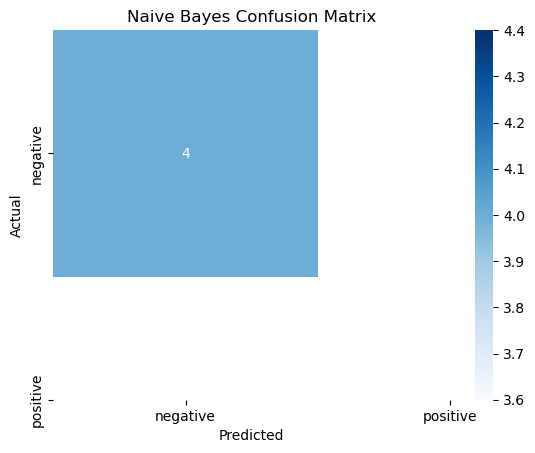

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, nb_predicted)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','positive'],
            yticklabels=['negative','positive'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()